<a href="https://colab.research.google.com/github/YuriArduino/Estudos_Visao_Computacional/blob/OCR-E-OPENCV/EasyOCR_e_OpenCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q --upgrade easyocr opencv-python sympy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 103.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 149.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.8/963.8 kB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 28.9 MB/s eta 0:00:00


In [2]:
import easyocr
import cv2

In [3]:
artigo = "https://cdn3.gnarususercontent.com.br/1802-deteccao-textos-imagens-easyocr/artigo.jpg"
placa_da_rua = "https://cdn3.gnarususercontent.com.br/1802-deteccao-textos-imagens-easyocr/placa_rua.png"

In [4]:
import requests

def download_image(url, save_path):
    response = requests.get(url)
    if response.status_code == 200:
        with open(save_path, 'wb') as f:
            f.write(response.content)
        print(f"Imagem baixada e salva em: {save_path}")
    else:
        print(f"Falha ao baixar a imagem de {url}")

# Caminhos para salvar as imagens
artigo_path = '/content/artigo.jpg'
placa_da_rua_path = '/content/placa_da_rua.png'

# Baixar as imagens
download_image(artigo, artigo_path)
download_image(placa_da_rua, placa_da_rua_path)

# Carregar as imagens usando cv2.imread
imagem_1 = cv2.imread(artigo_path)
imagem_2 = cv2.imread(placa_da_rua_path)

print(f"Imagem 1 carregada (shape): {imagem_1.shape if imagem_1 is not None else 'Erro ao carregar'}")
print(f"Imagem 2 carregada (shape): {imagem_2.shape if imagem_2 is not None else 'Erro ao carregar'}")

Imagem baixada e salva em: /content/artigo.jpg
Imagem baixada e salva em: /content/placa_da_rua.png
Imagem 1 carregada (shape): (1754, 1240, 3)
Imagem 2 carregada (shape): (772, 1028, 3)


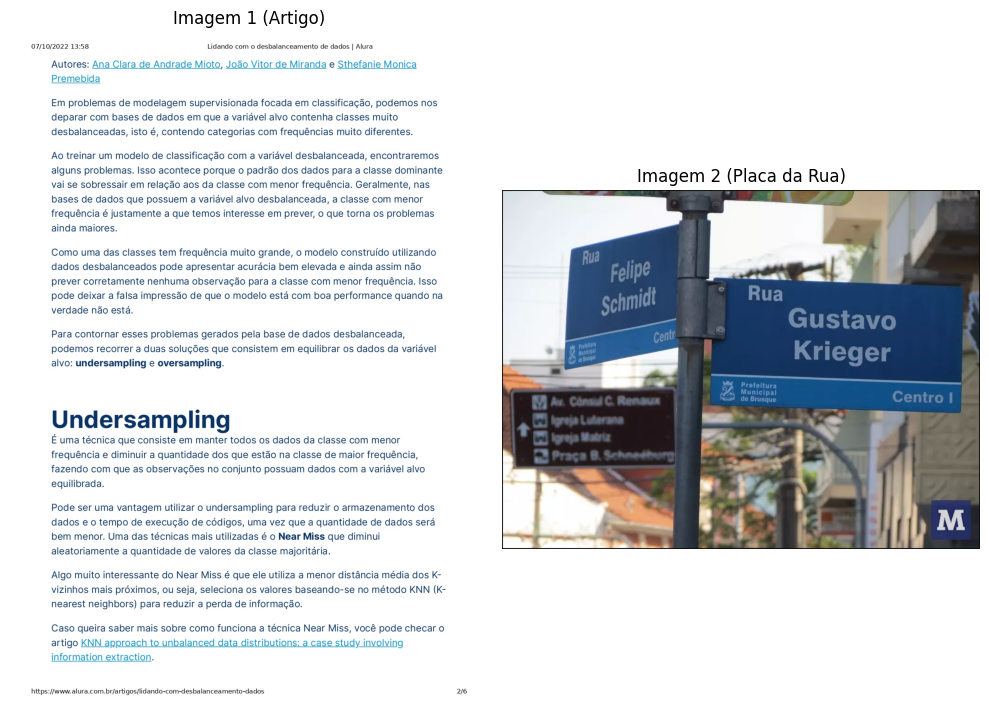

In [5]:
import matplotlib.pyplot as plt

# Convert BGR to RGB for correct display with matplotlib
image_1_rgb = cv2.cvtColor(imagem_1, cv2.COLOR_BGR2RGB)
image_2_rgb = cv2.cvtColor(imagem_2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.imshow(image_1_rgb)
plt.title('Imagem 1 (Artigo)')
plt.axis('off')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.imshow(image_2_rgb)
plt.title('Imagem 2 (Placa da Rua)')
plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
leitor = easyocr.Reader(lang_list=['pt'], gpu=True)

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

In [7]:
print("\n".join(leitor.readtext(imagem_1, detail=0)))

07/10/2022 13.58
Lidando com
desbalanceamento de dados
Alura
Autores: Ana Clara_de_Andrade Mioto, João_Vitor de Miranda
Sthefanie Monica
Premebida
Em problemas de modelagem supervisionada focada em classificação; podemos nos
deparar com bases de dados em que a variável alvo contenha classes muito
desbalanceadas, isto é, contendo categorias com frequências muito diferentes.
Ao treinar um modelo de classificação com
variável desbalanceada, encontraremos
alguns problemas. Isso acontece porque 0 padrão dos dados para
a classe dominante
vai se sobressair em relação aos da classe com menor frequência. Geralmente; nas
bases de dados que possuem
variável alvo desbalanceada, a classe com menor
frequência é justamente
que temos interesse em prever, 0 que torna os problemas
ainda maiores.
Como uma das classes tem
frequência muito grande, 0 modelo construído utilizando
dados desbalanceados pode apresentar acurácia bem elevada e ainda assim não
prever corretamente nenhuma observação para
a classe c

In [8]:
print("\n".join(leitor.readtext(imagem_1, detail=0, paragraph=True)))

07/10/2022 13.58
Lidando com desbalanceamento de dados Alura
Autores: Ana Clara_de_Andrade Mioto, João_Vitor de Miranda Sthefanie Monica Premebida
Em problemas de modelagem supervisionada focada em classificação; podemos nos deparar com bases de dados em que a variável alvo contenha classes muito desbalanceadas, isto é, contendo categorias com frequências muito diferentes.
Ao treinar um modelo de classificação com variável desbalanceada, encontraremos alguns problemas. Isso acontece porque 0 padrão dos dados para a classe dominante vai se sobressair em relação aos da classe com menor frequência. Geralmente; nas bases de dados que possuem variável alvo desbalanceada, a classe com menor frequência é justamente que temos interesse em prever, 0 que torna os problemas ainda maiores.
Como uma das classes tem frequência muito grande, 0 modelo construído utilizando dados desbalanceados pode apresentar acurácia bem elevada e ainda assim não prever corretamente nenhuma observação para a classe c

In [9]:
resultado  = leitor.readtext(image = imagem_2)
resultado

[([[np.int32(167), np.int32(125)],
   [np.int32(217), np.int32(125)],
   [np.int32(217), np.int32(167)],
   [np.int32(167), np.int32(167)]],
  'Rua',
  np.float64(0.9847167892754664)),
 ([[np.int32(225), np.int32(143)],
   [np.int32(329), np.int32(143)],
   [np.int32(329), np.int32(207)],
   [np.int32(225), np.int32(207)]],
  'Felipe',
  np.float64(0.9504853468920106)),
 ([[np.int32(524), np.int32(198)],
   [np.int32(610), np.int32(198)],
   [np.int32(610), np.int32(246)],
   [np.int32(524), np.int32(246)]],
  'Rua',
  np.float64(0.9995373692250141)),
 ([[np.int32(608), np.int32(242)],
   [np.int32(859), np.int32(242)],
   [np.int32(859), np.int32(316)],
   [np.int32(608), np.int32(316)]],
  'Gustavo',
  np.float64(0.9592266601362415)),
 ([[np.int32(163), np.int32(327)],
   [np.int32(205), np.int32(327)],
   [np.int32(205), np.int32(345)],
   [np.int32(163), np.int32(345)]],
  'Preleilura',
  np.float64(0.4377037290490258)),
 ([[np.int32(616), np.int32(309)],
   [np.int32(849), np.int3

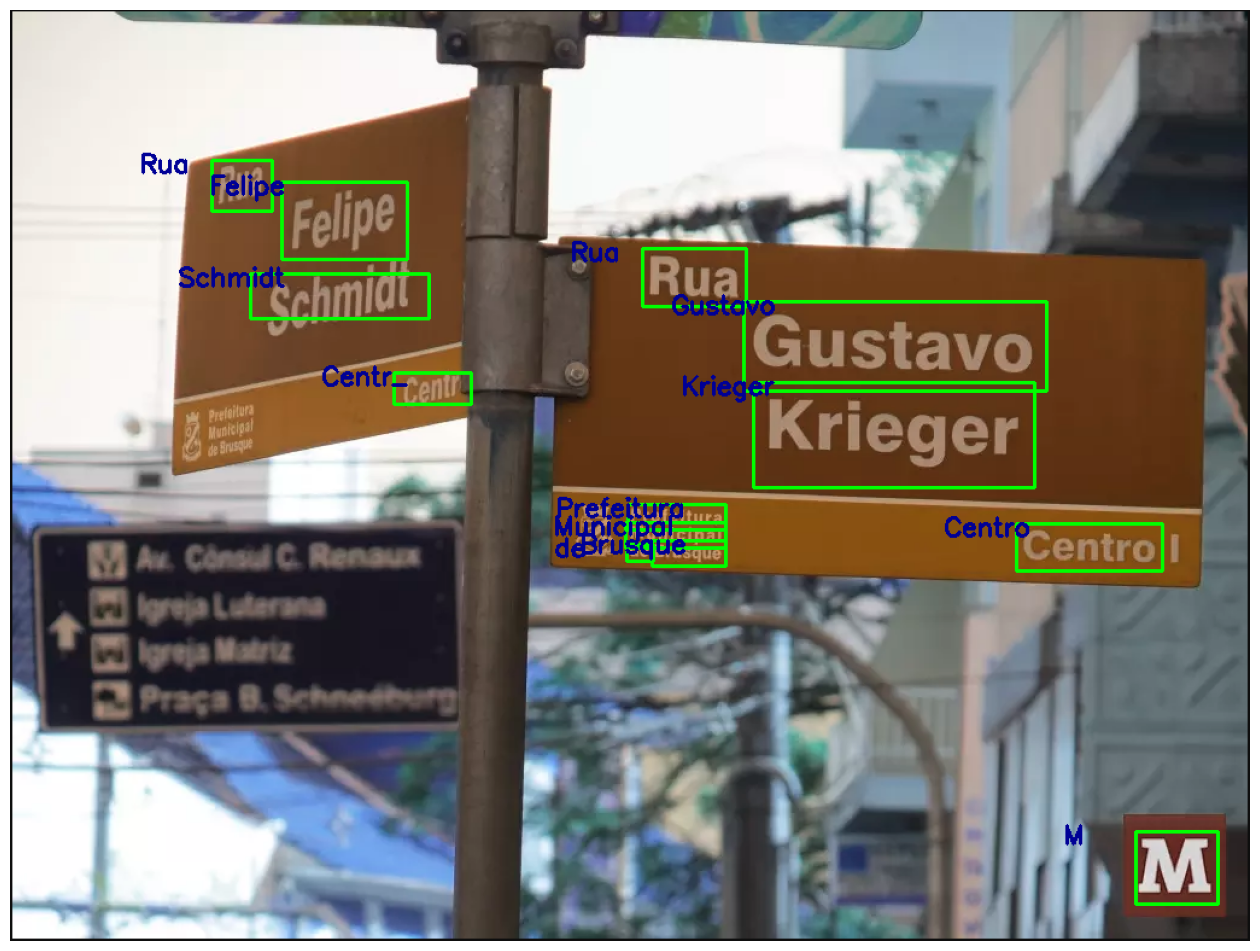

In [10]:
import matplotlib.pyplot as plt

for (coordenadas, texto, probabilidade) in resultado:
    if probabilidade > 0.7:
      (sup_esq, sup_dir, inf_dir, inf_esq) = coordenadas
      sup_esq = (int(sup_esq[0]), int(sup_esq[1]))
      sup_dir = (int(sup_dir[0]), int(sup_dir[1]))
      inf_dir = (int(inf_dir[0]), int(inf_dir[1]))
      inf_esq = (int(inf_esq[0]), int(inf_esq[1]))
      cv2.rectangle(imagem_2, sup_esq, inf_dir, (0, 255, 0), 2)
      cv2.putText(imagem_2, texto, (sup_esq[0] - 60, sup_esq[1] + 10),
      cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 150), 2)
plt.figure(figsize=(16, 16))
plt.axis('off')
plt.imshow(imagem_2);